In [1]:
!pip install -q --upgrade "scikit-learn==1.5.2" "scikeras==0.13.0"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scikeras.wrappers import KerasClassifier
import time
import os

os.makedirs("/kaggle/working/plots", exist_ok=True)
PLOT_DIR = "/kaggle/working/plots"

np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 79.1 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


KeyboardInterrupt: 

Cell 2 — Task 1: Dataset Exploration

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)
Number of classes: 10


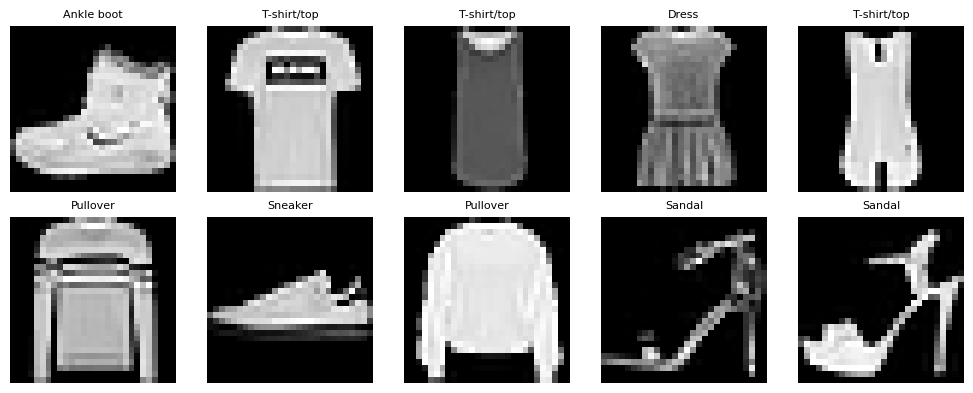

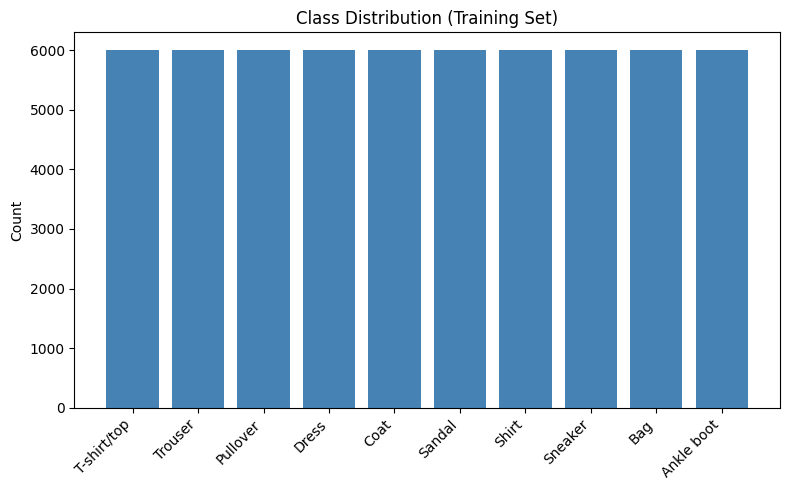

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("Number of classes:", len(np.unique(y_train)))

# Plot 1: Sample Images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/1_sample_images.png", dpi=300)
plt.show()

# Plot 2: Class Distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Class Distribution (Training Set)")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/2_class_distribution.png", dpi=300)
plt.show()

Cell 3 — Task 2: Preprocessing

In [6]:
print("Before preprocessing:", x_train.shape, x_test.shape)

x_train_flat = x_train.reshape(x_train.shape[0], -1).astype('float32') / 255.0
x_test_flat = x_test.reshape(x_test.shape[0], -1).astype('float32') / 255.0

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

print("After preprocessing:", x_train_flat.shape, x_test_flat.shape)
print("Labels one-hot shape:", y_train_oh.shape, y_test_oh.shape)

Before preprocessing: (60000, 28, 28) (10000, 28, 28)
After preprocessing: (60000, 784) (10000, 784)
Labels one-hot shape: (60000, 10) (10000, 10)


Cell 4 — Task 3: Model Construction

In [7]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

I0000 00:00:1784709700.197951      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784709700.200808      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Cell 5 — Task 4: Training

Epoch 1/20
  75/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4909 - loss: 1.5003

I0000 00:00:1784709801.644864     142 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8202 - loss: 0.5060 - val_accuracy: 0.8515 - val_loss: 0.3971
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8645 - loss: 0.3743 - val_accuracy: 0.8658 - val_loss: 0.3574
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8757 - loss: 0.3376 - val_accuracy: 0.8633 - val_loss: 0.3706
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8852 - loss: 0.3126 - val_accuracy: 0.8685 - val_loss: 0.3604
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8906 - loss: 0.2937 - val_accuracy: 0.8705 - val_loss: 0.3602
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8963 - loss: 0.2771 - val_accuracy: 0.8708 - val_loss: 0.3622
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9002 - loss: 0.2657 - val_accuracy: 0.8717 - val_loss: 0.3724
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9046 - loss: 0.2532 - val_accurac

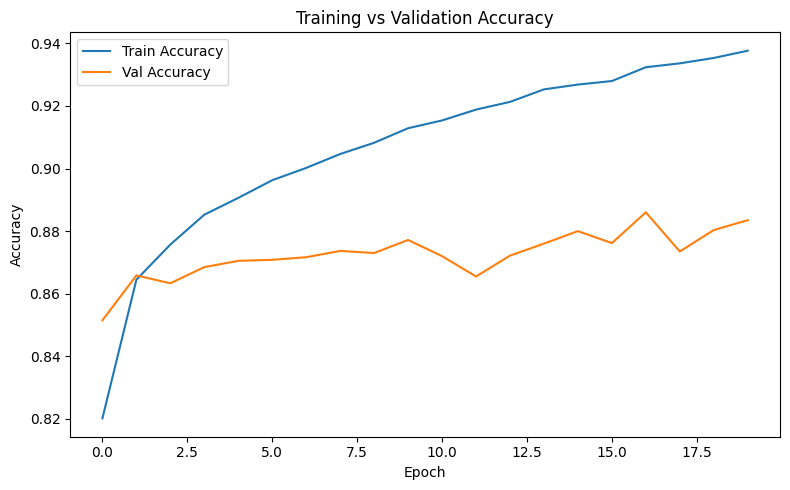

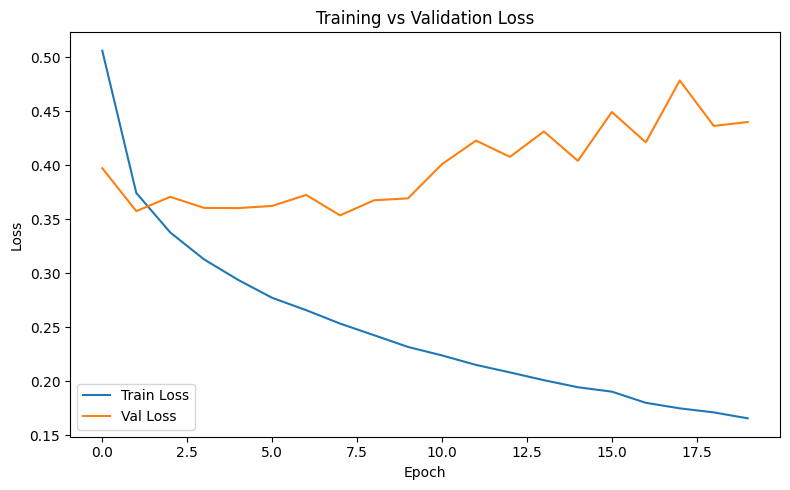

In [8]:
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

start_time = time.time()
history = baseline_model.fit(x_train_flat, y_train_oh,
                              validation_split=0.1,
                              epochs=20,
                              batch_size=32,
                              verbose=1)
baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f} sec")

# Plot 3 & 4: Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(); plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/3_4_accuracy_vs_epoch.png", dpi=300)
plt.show()

# Plot 5 & 6: Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(); plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/5_6_loss_vs_epoch.png", dpi=300)
plt.show()

Cell 6 — Task 5: Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Accuracy:  0.8791
Baseline Precision: 0.8810
Baseline Recall:    0.8791
Baseline F1-score:  0.8771

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.78      0.86      0.82      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.74      0.84      0.79      1000
       Dress       0.83      0.93      0.87      1000
        Coat       0.83      0.78      0.80      1000
      Sandal       0.96      0.95      0.96      1000
       Shirt       0.82      0.59      0.68      1000
     Sneaker       0.92      0.96      0.94      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



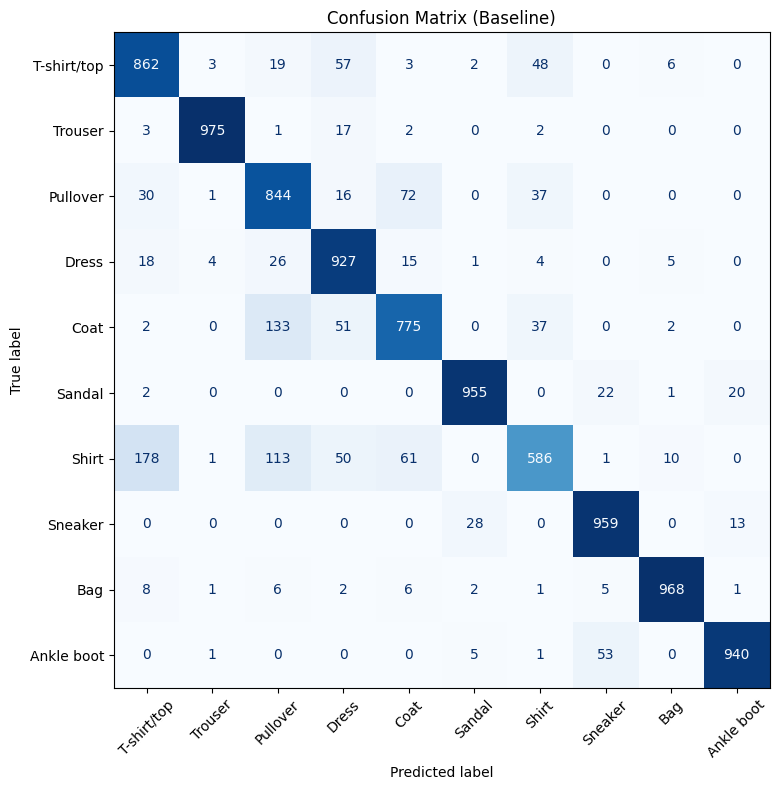

In [9]:
y_pred_probs = baseline_model.predict(x_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)

baseline_acc = accuracy_score(y_test, y_pred)
baseline_prec = precision_score(y_test, y_pred, average='macro')
baseline_rec = recall_score(y_test, y_pred, average='macro')
baseline_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Baseline Accuracy:  {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_prec:.4f}")
print(f"Baseline Recall:    {baseline_rec:.4f}")
print(f"Baseline F1-score:  {baseline_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Plot 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix (Baseline)")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/7_confusion_matrix.png", dpi=300)
plt.show()

Cell 7 — Hyperparameter Search Setup

In [11]:
# Full grid x 5-fold CV on 60k images is too expensive to run directly.
# Search on a stratified 6,000-image subsample; retrain winner on full data.

x_search, _, y_search, _ = train_test_split(
    x_train_flat, y_train, train_size=6000, stratify=y_train, random_state=42
)

def build_tunable_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                         optimizer_name='adam', activation='relu', dropout_rate=0.0,
                         meta=None):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    if optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

clf = KerasClassifier(
    model=build_tunable_model,
    hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
    optimizer_name='adam', activation='relu', dropout_rate=0.0,
    epochs=10, batch_size=32, verbose=0
)

param_dist = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5],
}

Cell 8 — Run the Search

In [12]:
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    n_jobs=1,
    random_state=42
)

search_start = time.time()
random_search.fit(x_search, y_search)
search_time = time.time() - search_start
print(f"Hyperparameter search time: {search_time:.2f} sec")

print("Best parameters found:")
print(random_search.best_params_)
print("Best CV accuracy:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.9s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.4s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.4s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.6s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   5.5s
[CV] END activation=relu, batch_size=16, dropout_rate=0.5, epochs=20, hidden_layers=3, hidden

Cell 9 — Plot 8: Search Results

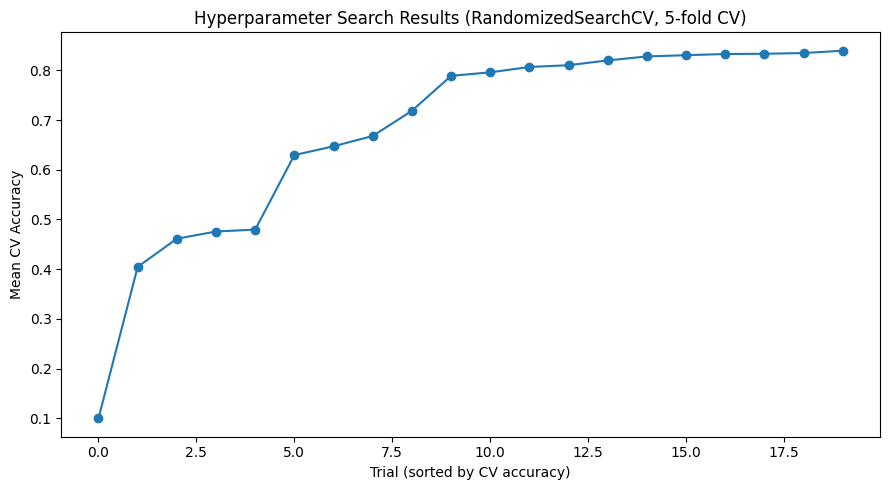

In [13]:
results = random_search.cv_results_
mean_scores = results['mean_test_score']

plt.figure(figsize=(9, 5))
plt.plot(range(len(mean_scores)), sorted(mean_scores), marker='o')
plt.xlabel("Trial (sorted by CV accuracy)")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results (RandomizedSearchCV, 5-fold CV)")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/8_hyperparam_search_results.png", dpi=300)
plt.show()

Cell 10 — Retrain Optimized Model on Full Data

In [15]:
best_params = random_search.best_params_

optimized_model = build_tunable_model(
    hidden_layers=best_params['hidden_layers'],
    hidden_neurons=best_params['hidden_neurons'],
    learning_rate=best_params['learning_rate'],
    optimizer_name=best_params['optimizer_name'],
    activation=best_params['activation'],
    dropout_rate=best_params['dropout_rate'],
)

opt_start = time.time()
optimized_model.fit(x_train_flat, y_train,
                     validation_split=0.1,
                     epochs=best_params['epochs'],
                     batch_size=best_params['batch_size'],
                     verbose=1)
optimized_train_time = time.time() - opt_start
print(f"Optimized model training time: {optimized_train_time:.2f} sec")

y_pred_opt_probs = optimized_model.predict(x_test_flat)
y_pred_opt = np.argmax(y_pred_opt_probs, axis=1)

opt_acc = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average='macro')
opt_rec = recall_score(y_test, y_pred_opt, average='macro')
opt_f1 = f1_score(y_test, y_pred_opt, average='macro')

print(f"Optimized Accuracy:  {opt_acc:.4f}")
print(f"Optimized Precision: {opt_prec:.4f}")
print(f"Optimized Recall:    {opt_rec:.4f}")
print(f"Optimized F1-score:  {opt_f1:.4f}")

Epoch 1/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8155 - loss: 0.5157 - val_accuracy: 0.8608 - val_loss: 0.3925
Epoch 2/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8562 - loss: 0.3972 - val_accuracy: 0.8633 - val_loss: 0.3761
Epoch 3/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8671 - loss: 0.3612 - val_accuracy: 0.8690 - val_loss: 0.3626
Epoch 4/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8739 - loss: 0.3419 - val_accuracy: 0.8673 - val_loss: 0.3740
Epoch 5/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8788 - loss: 0.3262 - val_accuracy: 0.8702 - val_loss: 0.3481
Epoch 6/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8845 - loss: 0.3116 - val_accuracy: 0.8767 - val_loss: 0.3541
Epoch 7/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8868 - loss: 0.3023 - val_accuracy: 0.8745 - val_loss: 0.3533
Epoch 8/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8904 - loss: 0.2917 -

Cell 11 — Plot 9: Comparison

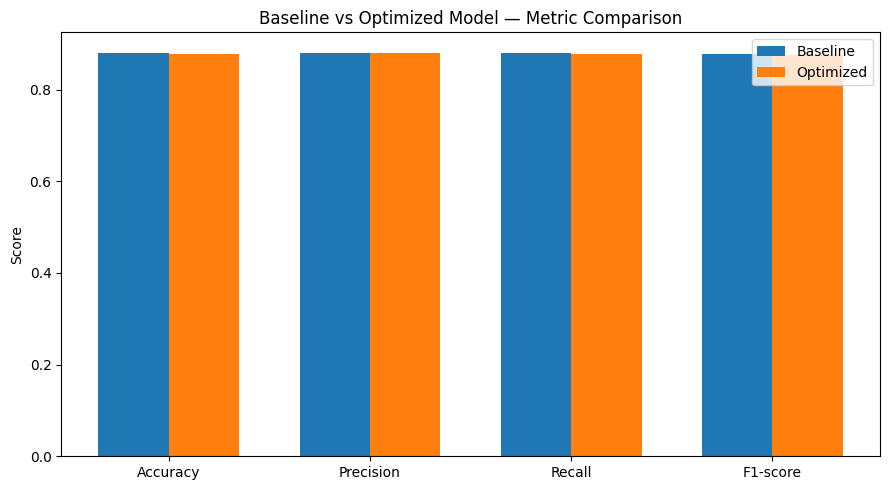

In [16]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
baseline_vals = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
optimized_vals = [opt_acc, opt_prec, opt_rec, opt_f1]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, baseline_vals, width, label='Baseline')
plt.bar(x + width/2, optimized_vals, width, label='Optimized')
plt.xticks(x, metrics_names)
plt.ylabel("Score")
plt.title("Baseline vs Optimized Model — Metric Comparison")
plt.legend(); plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/9_best_model_comparison.png", dpi=300)
plt.show()

Cell 12 — Final Summary

In [17]:
print("=" * 55)
print("BEST HYPERPARAMETERS")
print("=" * 55)
for k, v in best_params.items():
    print(f"{k}: {v}")
print(f"Cross-validation Accuracy: {random_search.best_score_:.4f}")
print(f"Testing Accuracy: {opt_acc:.4f}")

print("\n" + "=" * 55)
print("PERFORMANCE COMPARISON")
print("=" * 55)
print(f"{'Metric':<15}{'Baseline':<15}{'Optimized':<15}")
print(f"{'Accuracy':<15}{baseline_acc:<15.4f}{opt_acc:<15.4f}")
print(f"{'Precision':<15}{baseline_prec:<15.4f}{opt_prec:<15.4f}")
print(f"{'Recall':<15}{baseline_rec:<15.4f}{opt_rec:<15.4f}")
print(f"{'F1-score':<15}{baseline_f1:<15.4f}{opt_f1:<15.4f}")
print(f"{'Training Time':<15}{baseline_train_time:<15.2f}{optimized_train_time:<15.2f}")

BEST HYPERPARAMETERS
optimizer_name: adam
learning_rate: 0.001
hidden_neurons: 256
hidden_layers: 1
epochs: 20
dropout_rate: 0.2
batch_size: 16
activation: relu
Cross-validation Accuracy: 0.8393
Testing Accuracy: 0.8788

PERFORMANCE COMPARISON
Metric         Baseline       Optimized      
Accuracy       0.8791         0.8788         
Precision      0.8810         0.8811         
Recall         0.8791         0.8788         
F1-score       0.8771         0.8758         
Training Time  84.85          157.84         


Cell 13 — Zip and Download Plots

In [18]:
import shutil
shutil.make_archive('/kaggle/working/plots', 'zip', PLOT_DIR)
print("Zipped to /kaggle/working/plots.zip")
print("Download it from the Output tab on the right side of the Kaggle notebook.")

Zipped to /kaggle/working/plots.zip
Download it from the Output tab on the right side of the Kaggle notebook.
